# 05a — Prediction Grid

Applies the best trained model (Random Forest v2) to a 500 m prediction grid across
Córdoba Province to produce the wildfire susceptibility map.

**Outputs:**
- `outputs/susceptibility.tif` — 2-band GeoTIFF (Band 1 = probability, Band 2 = risk class 1–4)
- `outputs/susceptibility_zones.geojson` — risk zones dissolved by class (for dashboard)
- `outputs/susceptibility_map.png` — quick-look figure

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

# Allow importing extract_features.py directly
sys.path.insert(0, '../data/processing')

import json
import pickle
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mapclassify

from extract_features import (
    extract_raster_features,
    aggregate_soil_depths,
    get_osm_vectors,
    compute_osm_distances,
)

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')
MODELS    = Path('../models')
OUTPUTS.mkdir(exist_ok=True)

GRID_RES   = 0.005   # degrees (~500 m at 32°S)
BATCH_SIZE = 50_000  # points per raster extraction batch

print('Setup complete.')

Setup complete.


## 1 — Generate 500 m grid over Córdoba Province

In [2]:
boundary = gpd.read_file(RAW / 'cordoba_boundary.shp').to_crs('EPSG:4326')
boundary_poly = boundary.geometry.union_all()
minx, miny, maxx, maxy = boundary.total_bounds
print(f'Córdoba bbox: lon [{minx:.3f}, {maxx:.3f}]  lat [{miny:.3f}, {maxy:.3f}]')

# Regular grid
lons_1d = np.arange(minx, maxx + GRID_RES, GRID_RES)
lats_1d = np.arange(maxy, miny - GRID_RES, -GRID_RES)  # top → bottom
n_rows, n_cols = len(lats_1d), len(lons_1d)
print(f'Full grid: {n_rows} rows × {n_cols} cols = {n_rows * n_cols:,} cells')

LON_GRID, LAT_GRID = np.meshgrid(lons_1d, lats_1d)
all_lons = LON_GRID.ravel()
all_lats = LAT_GRID.ravel()
row_idx  = np.repeat(np.arange(n_rows), n_cols)
col_idx  = np.tile(np.arange(n_cols), n_rows)

# Filter to points within the province boundary
grid_gdf = gpd.GeoDataFrame(
    {'lon': all_lons, 'lat': all_lats, 'row': row_idx, 'col': col_idx},
    geometry=gpd.points_from_xy(all_lons, all_lats),
    crs='EPSG:4326'
)
valid_gdf = gpd.sjoin(grid_gdf, boundary[['geometry']], how='inner', predicate='within')
valid_gdf = valid_gdf.drop(columns=['index_right'], errors='ignore').reset_index(drop=True)

lons   = valid_gdf['lon'].values
lats   = valid_gdf['lat'].values
v_rows = valid_gdf['row'].values
v_cols = valid_gdf['col'].values

print(f'Valid cells inside boundary: {len(lons):,}  '
      f'({100 * len(lons) / (n_rows * n_cols):.1f}% of full grid)')

Córdoba bbox: lon [-65.778, -61.778]  lat [-34.999, -29.503]
Full grid: 1101 rows × 802 cols = 883,002 cells


Valid cells inside boundary: 629,777  (71.3% of full grid)


## 2 — Extract raster features (batched)

In [3]:
n_points = len(lons)
n_batches = int(np.ceil(n_points / BATCH_SIZE))
print(f'Extracting rasters in {n_batches} batches of ≤{BATCH_SIZE:,} points...')

raster_chunks = []
for i in range(n_batches):
    lo = i * BATCH_SIZE
    hi = min(lo + BATCH_SIZE, n_points)
    print(f'\nBatch {i + 1}/{n_batches}  [{lo:,} – {hi:,}]')
    chunk = extract_raster_features(lons[lo:hi], lats[lo:hi])
    chunk = aggregate_soil_depths(chunk)
    raster_chunks.append(chunk)

raster_df = pd.concat(raster_chunks, ignore_index=True)
print(f'\nRaster extraction complete: {raster_df.shape}')

Extracting rasters in 13 batches of ≤50,000 points...

Batch 1/13  [0 – 50,000]


  elevation                     :     0 NaN / 50,000 total


  slope                         :     0 NaN / 50,000 total


  aspect_cos                    :     0 NaN / 50,000 total


  twi                           :     0 NaN / 50,000 total


...

  phh2o_5_15                    :     0 NaN / 29,777 total


  phh2o_15_30                   :     0 NaN / 29,777 total


  bdod_0_5                      :     0 NaN / 29,777 total


  bdod_5_15                     :     0 NaN / 29,777 total


  bdod_15_30                    :     0 NaN / 29,777 total

Raster extraction complete: (629777, 16)


## 3 — Compute OSM distances

In [4]:
print('Loading cached OSM vectors...')
osm_vectors = get_osm_vectors(boundary_poly, boundary.total_bounds)

print('\nComputing nearest distances...')
osm_df = compute_osm_distances(lons, lats, osm_vectors)
print('\nOSM distances done:', osm_df.shape)

Loading cached OSM vectors...
  Loading cached roads...


  Loading cached rivers...
  Loading cached settlements...

Computing nearest distances...


  Densifying roads geometries (500m spacing)...


  Building roads cKDTree (525,094 coords)...


  distance_to_road_km: min=0.00 km, mean=4.62 km, max=44.25 km
  Densifying rivers geometries (500m spacing)...


  Building rivers cKDTree (633,887 coords)...


  distance_to_river_km: min=0.00 km, mean=8.06 km, max=72.09 km
  Building settlements cKDTree (14 coords)...
  distance_to_settlement_km: min=0.00 km, mean=82.36 km, max=210.23 km

OSM distances done: (629777, 3)


## 4 — Assemble feature matrix

In [5]:
# Load feature metadata
with open(PROCESSED / 'selected_features_v2.json') as f:
    feat_meta = json.load(f)

MODEL_FEATURES  = feat_meta['all_model_features']     # 19 features
CONT_FEATURES   = feat_meta['continuous_features']    # 8 features
LC_FEATURES     = feat_meta['landcover_ohe_features'] # 11 features
POP_MEDIAN      = feat_meta['pop_density_impute_median']

print(f'Model expects {len(MODEL_FEATURES)} features: {MODEL_FEATURES}')

# Combine
grid_df = pd.concat(
    [raster_df.reset_index(drop=True), osm_df.reset_index(drop=True)],
    axis=1
)

# Impute population_density
grid_df['population_density'] = grid_df['population_density'].fillna(POP_MEDIAN)
print(f'population_density NaN after impute: {grid_df["population_density"].isna().sum()}')

# One-hot encode land cover
with open(PROCESSED / 'encoder_v2.pkl', 'rb') as f:
    encoder = pickle.load(f)

lc_values = grid_df['land_cover_class'].values.reshape(-1, 1)
# NaN land cover → use -1 so handle_unknown='ignore' produces all-zero OHE row
lc_values = np.where(np.isnan(lc_values.astype(float)), -1, lc_values)
ohe_array = encoder.transform(lc_values)
ohe_df = pd.DataFrame(ohe_array, columns=encoder.get_feature_names_out(['land_cover_class']))
# Rename to match training column names (lc_20, lc_30, ...)
ohe_df.columns = [c.replace('land_cover_class_', 'lc_') for c in ohe_df.columns]
# Add any missing LC columns (unseen classes → 0)
for col in LC_FEATURES:
    if col not in ohe_df.columns:
        ohe_df[col] = 0.0
ohe_df = ohe_df[LC_FEATURES]

# Scale continuous features
with open(PROCESSED / 'scaler_v2.pkl', 'rb') as f:
    scaler = pickle.load(f)

cont_array = grid_df[CONT_FEATURES].values
# Impute NaN with training feature means (z-score=0 after StandardScaler)
cont_nan_mask = np.isnan(cont_array)
if cont_nan_mask.any():
    col_means = scaler.mean_
    row_idx, col_idx = np.where(cont_nan_mask)
    cont_array[row_idx, col_idx] = col_means[col_idx]
    print(f'Imputed {cont_nan_mask.sum()} NaN values using training feature means')
scaled_cont = scaler.transform(cont_array)
scaled_cont_df = pd.DataFrame(scaled_cont, columns=CONT_FEATURES)

# Assemble final matrix
X_grid = pd.concat([scaled_cont_df, ohe_df], axis=1)[MODEL_FEATURES].values
print(f'X_grid shape: {X_grid.shape}  | NaN count: {np.isnan(X_grid).sum()}')

Model expects 27 features: ['elevation', 'slope', 'aspect_cos', 'twi', 'ndvi', 'lst', 'temperature', 'precipitation', 'wind_speed', 'population_density', 'soc', 'clay', 'phh2o', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km', 'lc_20', 'lc_30', 'lc_40', 'lc_50', 'lc_60', 'lc_80', 'lc_90', 'lc_114', 'lc_116', 'lc_124', 'lc_126']
population_density NaN after impute: 0


X_grid shape: (629777, 27)  | NaN count: 0


## 5 — Inference

In [6]:
with open(MODELS / 'randomforest_v2_best.pkl', 'rb') as f:
    rf_model = pickle.load(f)

print('Running inference...')
proba = rf_model.predict_proba(X_grid)[:, 1]

print(f'Probability stats:')
print(f'  min   = {proba.min():.4f}')
print(f'  mean  = {proba.mean():.4f}')
print(f'  max   = {proba.max():.4f}')
print(f'  >0.5  = {(proba > 0.5).sum():,} cells ({100*(proba>0.5).mean():.1f}%)')

Running inference...


Probability stats:
  min   = 0.0000
  mean  = 0.3886
  max   = 0.9998
  >0.5  = 158,560 cells (25.2%)


## 6 — Natural Breaks (Jenks) classification

In [7]:
# Natural Breaks into 4 risk zones
# mapclassify.NaturalBreaks uses Fisher-Jenks algorithm
classifier = mapclassify.NaturalBreaks(proba, k=4)
# yb: 0-indexed class assignment (0=lowest, 3=highest)
risk_class = (classifier.yb + 1).astype(np.uint8)  # 1=Low, 2=Moderate, 3=High, 4=Very High

RISK_LABELS = {1: 'Low', 2: 'Moderate', 3: 'High', 4: 'Very High'}
RISK_COLORS = {1: '#2ecc71', 2: '#f1c40f', 3: '#e67e22', 4: '#c0392b'}

breaks = np.concatenate([[proba.min()], classifier.bins])
print('Natural Breaks thresholds:')
for i, label in RISK_LABELS.items():
    lo = breaks[i - 1]
    hi = breaks[i]
    count = (risk_class == i).sum()
    pct   = 100 * count / len(risk_class)
    print(f'  {i} {label:10s}: [{lo:.4f}, {hi:.4f}]  {count:,} cells ({pct:.1f}%)')

# Sanity check: Very High should not exceed 20% of province
vh_pct = 100 * (risk_class == 4).sum() / len(risk_class)
print(f'\nVery High zone: {vh_pct:.1f}% — ', 'OK' if vh_pct < 20 else 'WARNING: >20%')

Natural Breaks thresholds:
  1 Low       : [0.0000, 0.1908]  86,911 cells (13.8%)
  2 Moderate  : [0.1908, 0.4034]  301,446 cells (47.9%)
  3 High      : [0.4034, 0.6611]  159,181 cells (25.3%)
  4 Very High : [0.6611, 0.9998]  82,239 cells (13.1%)

Very High zone: 13.1% —  OK


## 7 — Export GeoTIFF

In [8]:
# Reconstruct 2D grids (NaN where outside boundary)
prob_grid  = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
class_grid = np.full((n_rows, n_cols), 0,      dtype=np.float32)

prob_grid[v_rows, v_cols]  = proba.astype(np.float32)
class_grid[v_rows, v_cols] = risk_class.astype(np.float32)

# GeoTIFF transform: top-left corner, positive x-step, negative y-step
transform = from_bounds(minx, miny, maxx, maxy, n_cols, n_rows)

out_tif = OUTPUTS / 'susceptibility.tif'
with rasterio.open(
    out_tif, 'w',
    driver='GTiff',
    height=n_rows, width=n_cols,
    count=2,
    dtype='float32',
    crs='EPSG:4326',
    transform=transform,
    nodata=np.nan,
    compress='lzw',
) as dst:
    dst.update_tags(1, long_name='Fire susceptibility probability')
    dst.update_tags(2, long_name='Risk class (1=Low 2=Moderate 3=High 4=VeryHigh)')
    dst.write(prob_grid,  1)
    dst.write(class_grid, 2)

print(f'GeoTIFF saved → {out_tif}')
print(f'  Size: {out_tif.stat().st_size / 1e6:.1f} MB')

# Verify
with rasterio.open(out_tif) as src:
    print(f'  CRS: {src.crs}')
    print(f'  Shape: {src.height} rows × {src.width} cols, {src.count} bands')
    print(f'  Bounds: {src.bounds}')

GeoTIFF saved → ../outputs/susceptibility.tif
  Size: 3.5 MB
  CRS: EPSG:4326
  Shape: 1101 rows × 802 cols, 2 bands
  Bounds: BoundingBox(left=-65.7782592779999, bottom=-34.99873351899993, right=-61.77767181399997, top=-29.503320692999978)


## 8 — Export GeoJSON (dissolved risk zones)

In [9]:
half = GRID_RES / 2

# Build point GeoDataFrame then buffer to cell squares
zones_gdf = gpd.GeoDataFrame(
    {'risk_class': risk_class, 'risk_label': [RISK_LABELS[c] for c in risk_class], 'probability': proba},
    geometry=gpd.points_from_xy(lons, lats),
    crs='EPSG:4326'
)
zones_gdf['geometry'] = zones_gdf.geometry.buffer(half, cap_style=3)  # cap_style=3 → square

# Dissolve by risk class
dissolved = zones_gdf[['risk_class', 'risk_label', 'geometry']].dissolve(by='risk_class').reset_index()
dissolved = dissolved.sort_values('risk_class').reset_index(drop=True)

out_geojson = OUTPUTS / 'susceptibility_zones.geojson'
dissolved.to_file(out_geojson, driver='GeoJSON')

print(f'GeoJSON saved → {out_geojson}')
print(f'  Size: {out_geojson.stat().st_size / 1e6:.1f} MB')
print(f'  Features: {len(dissolved)} risk zones')
dissolved[['risk_class', 'risk_label']]

GeoJSON saved → ../outputs/susceptibility_zones.geojson
  Size: 33.1 MB
  Features: 4 risk zones


,risk_class,risk_label
0,1,Low
1,2,Moderate
2,3,High
3,4,Very High


## 9 — Quick-look susceptibility map

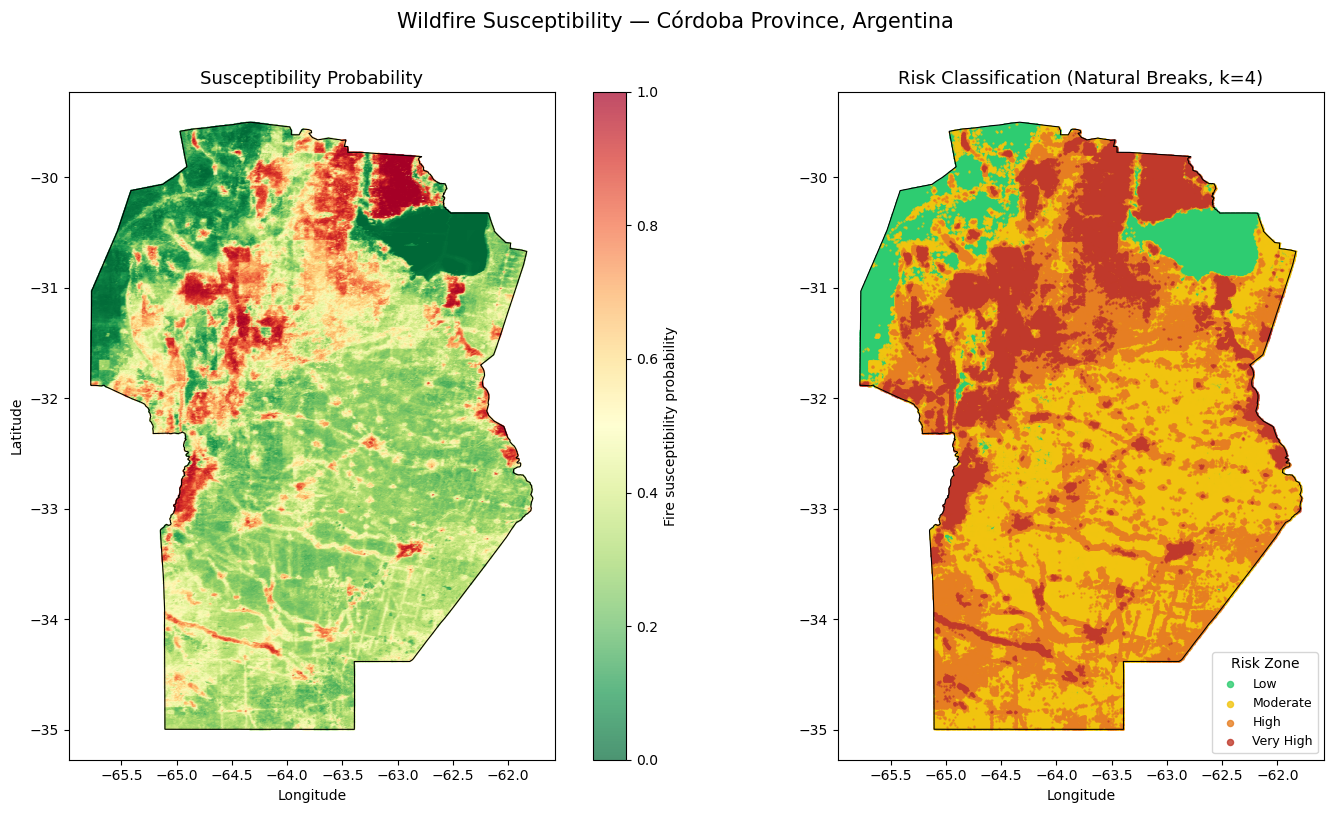

Map saved → ../outputs/susceptibility_map.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: continuous probability
ax = axes[0]
sc = ax.scatter(lons, lats, c=proba, cmap='RdYlGn_r', s=0.3, alpha=0.7, vmin=0, vmax=1)
boundary.boundary.plot(ax=ax, color='black', linewidth=0.8)
plt.colorbar(sc, ax=ax, label='Fire susceptibility probability')
ax.set_title('Susceptibility Probability', fontsize=13)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_aspect('equal')

# Right: discrete risk zones
ax = axes[1]
for cls, label in RISK_LABELS.items():
    mask = risk_class == cls
    ax.scatter(lons[mask], lats[mask], c=RISK_COLORS[cls], s=0.3, alpha=0.8, label=label)
boundary.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.legend(markerscale=8, title='Risk Zone', fontsize=9)
ax.set_title('Risk Classification (Natural Breaks, k=4)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_aspect('equal')

plt.suptitle('Wildfire Susceptibility — Córdoba Province, Argentina', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / 'susceptibility_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Map saved → {OUTPUTS}/susceptibility_map.png')

## 10 — Summary

In [11]:
total_area_km2 = len(lons) * (GRID_RES * 111) ** 2  # rough area estimate

print('=' * 50)
print('Phase 5A — Prediction Grid Summary')
print('=' * 50)
print(f'Grid resolution : {GRID_RES}° (~500 m)')
print(f'Valid cells     : {len(lons):,}')
print(f'Coverage area   : ~{total_area_km2:,.0f} km²')
print()
print('Risk zone distribution:')
for cls, label in RISK_LABELS.items():
    count = (risk_class == cls).sum()
    pct   = 100 * count / len(risk_class)
    area  = count * (GRID_RES * 111) ** 2
    print(f'  {label:10s}: {count:7,} cells ({pct:5.1f}%)  ~{area:,.0f} km²')
print()
print('Jenks break thresholds (upper bounds):')
for i, b in enumerate(classifier.bins):
    print(f'  {RISK_LABELS[i+1]:10s} ≤ {b:.4f}')
print()
print('Outputs:')
print(f'  {OUTPUTS}/susceptibility.tif')
print(f'  {OUTPUTS}/susceptibility_zones.geojson')
print(f'  {OUTPUTS}/susceptibility_map.png')
print('=' * 50)
print('Ready for 05b_validation.ipynb')

Phase 5A — Prediction Grid Summary
Grid resolution : 0.005° (~500 m)
Valid cells     : 629,777
Coverage area   : ~193,987 km²

Risk zone distribution:
  Low       :  86,911 cells ( 13.8%)  ~26,771 km²
  Moderate  : 301,446 cells ( 47.9%)  ~92,853 km²
  High      : 159,181 cells ( 25.3%)  ~49,032 km²
  Very High :  82,239 cells ( 13.1%)  ~25,332 km²

Jenks break thresholds (upper bounds):
  Low        ≤ 0.1908
  Moderate   ≤ 0.4034
  High       ≤ 0.6611
  Very High  ≤ 0.9998

Outputs:
  ../outputs/susceptibility.tif
  ../outputs/susceptibility_zones.geojson
  ../outputs/susceptibility_map.png
Ready for 05b_validation.ipynb
